<h1><center><b>Machine Learning</b></center></h1>
<h3><center>Exercise 5</center></h3>
<h4><center>K-Means and PCA<center></h4>

*Your* Name:  
<font color='red'>
Yehonatan Shemesh, 331050591   
</font>


**Instructions:**
- Create a copy of this notebook and implement your code in it.
- Ensure you don't leave any cells or answers empty.
- Do not change the code we provided.
- Modify code according the 'TODO' notes
- After completing the assignment, download this **notebook** (with your code and all outputs!) named ***Ex5_Machine_Learning.ipynb***, and submit it as a zip file named ***ex5.zip*** in the Lemida.
To Download the notebook go to **"File"** -> **"Download .ipynb"**.  
- Submit deadline: June 23, 2026

- Video Explanation Request:
- Please provide video explanations for your responses to questions (video mention appears in the relevant question as well):
1. K-Means – Explaining the results on convex and non-convex datasets (success vs. failure)
2. PCA – Explaining the difference between $V^TV$ and $VV^T$
- See instructions in the Lemida course site.
- The video component will constitute 10% of the overall grade, with each video accounting for 5%.
- Total of 2 videos.

All the video content as in previous assignments should be inside the zip file.

## Part 1 - K-Means (50%)

In this part you will have to implement the K-Means algorithm that was learned in class.<br>
**The implementation will be based on the numpy package only.**

### **1. Useful packages**

In [1]:
import matplotlib.pyplot as plt
import numpy as np

**All plots in this assignment are required to be generated using Matplotlib only; no other plotting libraries may be used.**

### **2. Data**

### **2.1 Convex Data**

Generate a convex 2D dataset

In [2]:
## Generate 2D data
X_convex = np.concatenate([
    np.random.normal([0, 0], size=(500, 2)),
    np.random.normal([5, 5], size=(500, 2)),
    np.random.normal([5, 0], size=(500, 2)),
    np.random.normal([0, 5], size=(500, 2)),
])

# Shuffle the data
np.random.shuffle(X_convex)

print(X_convex.shape)


(2000, 2)


Plot the a convex 2D dataset to explore how many clusters it contains

/tmp/ipykernel_20229/6372238.py:2: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(X_convex[:, 0], X_convex[:, 1], cmap='viridis')


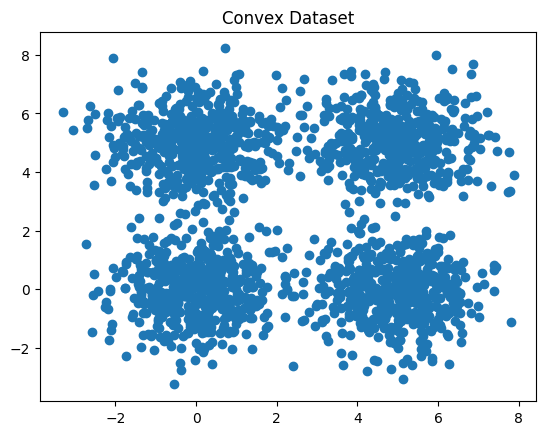

In [3]:
plt.title("Convex Dataset")
plt.scatter(X_convex[:, 0], X_convex[:, 1], cmap='viridis')

### **2.2 Non-Convex Data**

Generate a non-convex 2D dataset

In [4]:
from sklearn.datasets import make_moons
import matplotlib.pyplot as plt

X_non_convex, y = make_moons(n_samples=300, noise=0.05, random_state=42)


Plot the non convex 2D dataset to explore how many clusters it contains

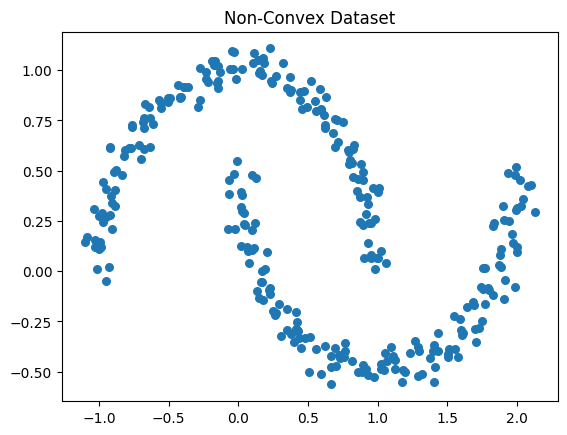

In [5]:
plt.scatter(X_non_convex[:, 0], X_non_convex[:, 1], s=30)
plt.title("Non-Convex Dataset")
plt.show()

### **3. K-Means**

Implement the algorithm

In [6]:
class KMeans():
    def __init__(self, n_clusters=8, max_iter=300):
        self.n_clusters = n_clusters
        self.max_iter = max_iter

        ######## Helper fields #########
        self.X_fit_ = None      # Here you should store the dataset X.
                                # This can be useful for the next tasks.

        self.labels_ = None     # Here you should store the final labels.
                                # That is, the clusters indices for all the samples

        self.centroids = None   # Here you should store the final centroids.

        self.labels_history = []    # Here you should store the labels of each iteration.
                                    # This can also be useful later.

        self.centroids_history = [] # Here you should store the centroids of each iteration.
                                    # This can also be useful later.

        self.costs = []             # Here you should store the costs of the iterations.
                                    # That is, you should calculate the cost in every iteration
                                    # and store it in this list.


    def fit(self, X):
        self.X_fit_ = X
        # Initialize centroids randomly from the dataset
        random_indices = np.random.choice(X.shape[0], self.n_clusters, replace=False)
        self.centroids = X[random_indices]

        for _ in range(self.max_iter):
            labels = self._get_labels(X)
            self.labels_history.append(labels)
            self.centroids_history.append(self.centroids.copy())

            # Calculate and store cost
            cost = self._calculate_cost(X)
            self.costs.append(cost)

            # Update centroids
            new_centroids = self._get_centroids(X, labels)

            # Check for convergence
            if np.all(self.centroids == new_centroids):
                break

            self.centroids = new_centroids

        self.labels_ = self._get_labels(X)

    def predict(self, X):
        return self._get_labels(X)

    def _get_distances(self, X):
        # Calculate Euclidean distance from each point to each centroid
        distances = np.zeros((X.shape[0], self.n_clusters))
        for i, centroid in enumerate(self.centroids):
            distances[:, i] = np.linalg.norm(X - centroid, axis=1)
        return distances

    def _get_labels(self, X):
        distances = self._get_distances(X)
        return np.argmin(distances, axis=1) # Assign to the closest centroid

    def _get_centroids(self, X, labels):
        centroids = np.zeros((self.n_clusters, X.shape[1]))
        for i in range(self.n_clusters):
            cluster_points = X[labels == i]
            if len(cluster_points) > 0:
                centroids[i] = cluster_points.mean(axis=0)
            else:
                # If a cluster becomes empty, randomly reinitialize it
                centroids[i] = X[np.random.choice(X.shape[0])]
        return centroids

    def _calculate_cost(self, X):
        # Cost is the sum of squared distances to the closest centroid
        distances = self._get_distances(X)
        min_distances = np.min(distances, axis=1)
        return np.sum(min_distances ** 2)

### **3.1 K-Means Using Convex Data**

Run the algorithm on the 2D convex dataset

In [7]:
n_clusters = 4
kmeans = KMeans(n_clusters=n_clusters)
kmeans.fit(X_convex)

Plot a graph of the costs as a function of the iterations

> Add blockquote



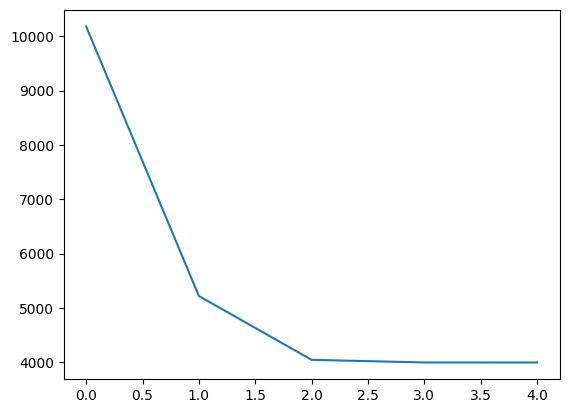

In [8]:
costs = kmeans.costs
plt.plot(costs)

In [9]:
k_values = [2, 3, 4, 6, 8, 10, 20]

print("Final costs for Convex Data:")
for k in k_values:
    kmeans = KMeans(n_clusters=k)
    kmeans.fit(X_convex)
    print(f"{k} clusters: {kmeans.costs[-1]:.2f}")

Final costs for Convex Data:
2 clusters: 16417.52
3 clusters: 10392.66
4 clusters: 3995.55
6 clusters: 3288.69
8 clusters: 2720.73
10 clusters: 2386.03
20 clusters: 1142.10


Now run the algorithm several more times with n_clusters = 2, 3, 4, 6, 8, 10, 20 and write **below** the **final** cost you got in each experiment.<br>

2 clusters: 16417.52 <br>
3 clusters: 10392.66 <br>
4 clusters: 3995.55 <br>
6 clusters: 3288.69 <br>
8 clusters: 2720.73 <br>
10 clusters: 2386.03 <br>
20 clusters: 1142.10 <br>

Now write a code that plots the clusters and the locations of the centroids at each iteration

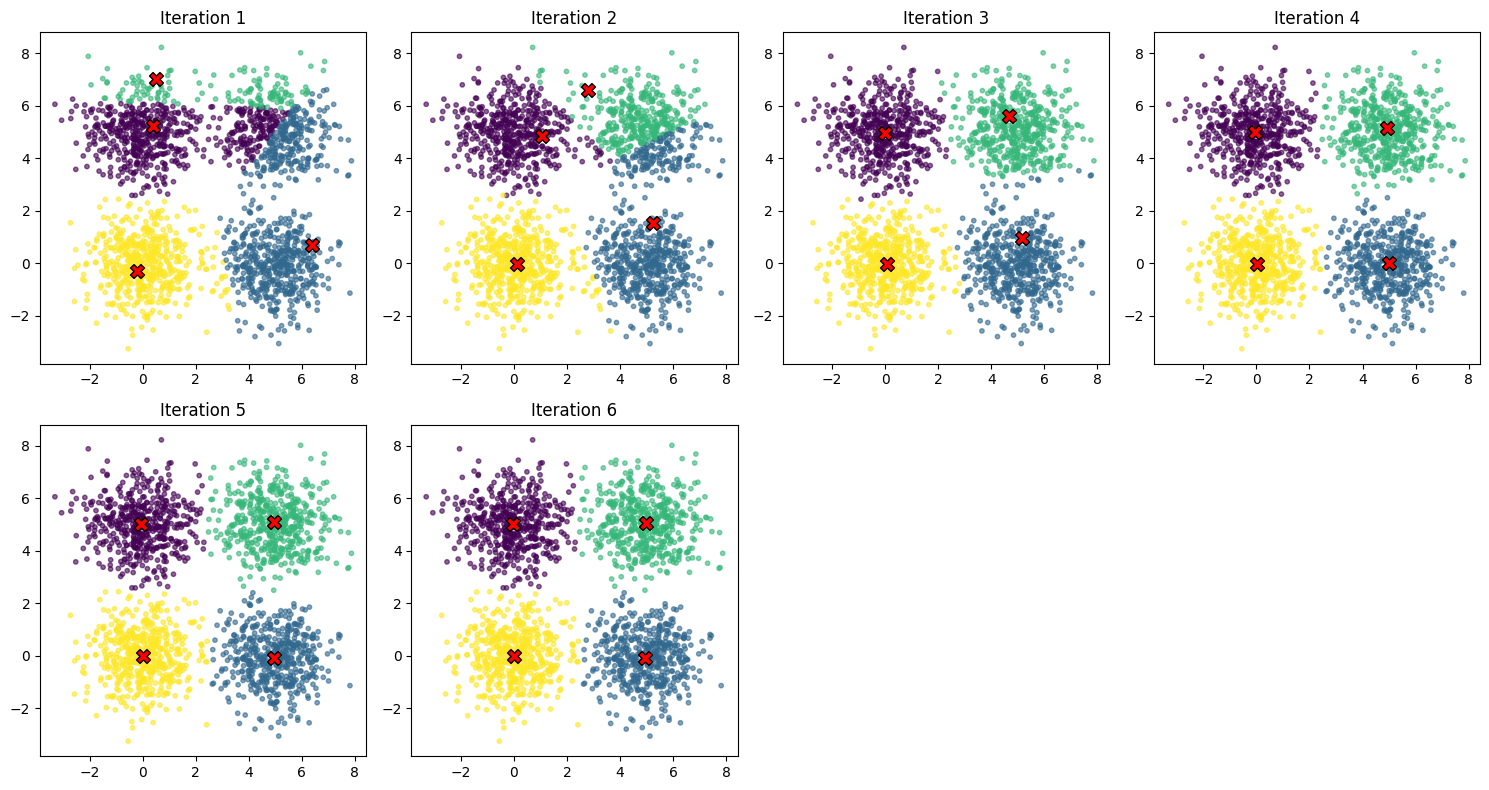

In [23]:
# Re-run with k=4 to capture a clean history for plotting
kmeans_plot = KMeans(n_clusters=4)
kmeans_plot.fit(X_convex)

iters = len(kmeans_plot.centroids_history)
cols = min(4, iters)
rows = (iters + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(15, 4 * rows))
axes = np.array(axes).flatten()

for i in range(iters):
    ax = axes[i]
    ax.scatter(X_convex[:, 0], X_convex[:, 1], c=kmeans_plot.labels_history[i], cmap='viridis', s=10, alpha=0.6)
    ax.scatter(kmeans_plot.centroids_history[i][:, 0], kmeans_plot.centroids_history[i][:, 1],
               c='red', marker='X', s=100, edgecolors='black')
    ax.set_title(f'Iteration {i+1}')

# Hide any empty subplots
for i in range(iters, len(axes)):
    axes[i].axis('off')

plt.tight_layout()
plt.show()

### **3.1 K-Means Using Non-Convex Data**

Run the algorithm on the 2D non-convex dataset

In [11]:
n_clusters = 4
kmeans = KMeans(n_clusters=n_clusters)
kmeans.fit(X_non_convex)

Plot a graph of the costs as a function of the iterations

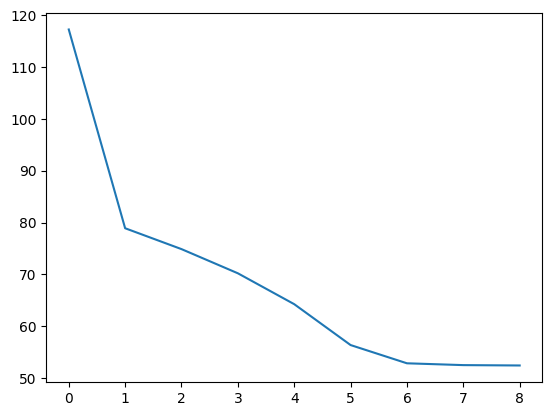

In [12]:
costs = kmeans.costs
plt.plot(costs)

In [13]:
k_values = [2, 3, 4, 6, 8, 10, 20]

print("Final costs for Non-Convex Data:")
for k in k_values:
    kmeans = KMeans(n_clusters=k)
    kmeans.fit(X_non_convex)
    print(f"{k} clusters: {kmeans.costs[-1]:.2f}")

Final costs for Non-Convex Data:
2 clusters: 121.01
3 clusters: 80.04
4 clusters: 52.41
6 clusters: 35.75
8 clusters: 17.57
10 clusters: 13.26
20 clusters: 6.03


Now run the algorithm several more times with n_clusters = 2, 3, 4, 6, 8, 10, 20 and write **below** the **final** cost you got in each experiment.<br>

2 clusters: 121.01 <br>
3 clusters: 80.04 <br>
4 clusters: 52.41 <br>
6 clusters: 35.75 <br>
8 clusters: 17.57 <br>
10 clusters: 13.26 <br>
20 clusters: 6.03 <br>

Now write a code that plots the clusters and the locations of the centroids at each iteration

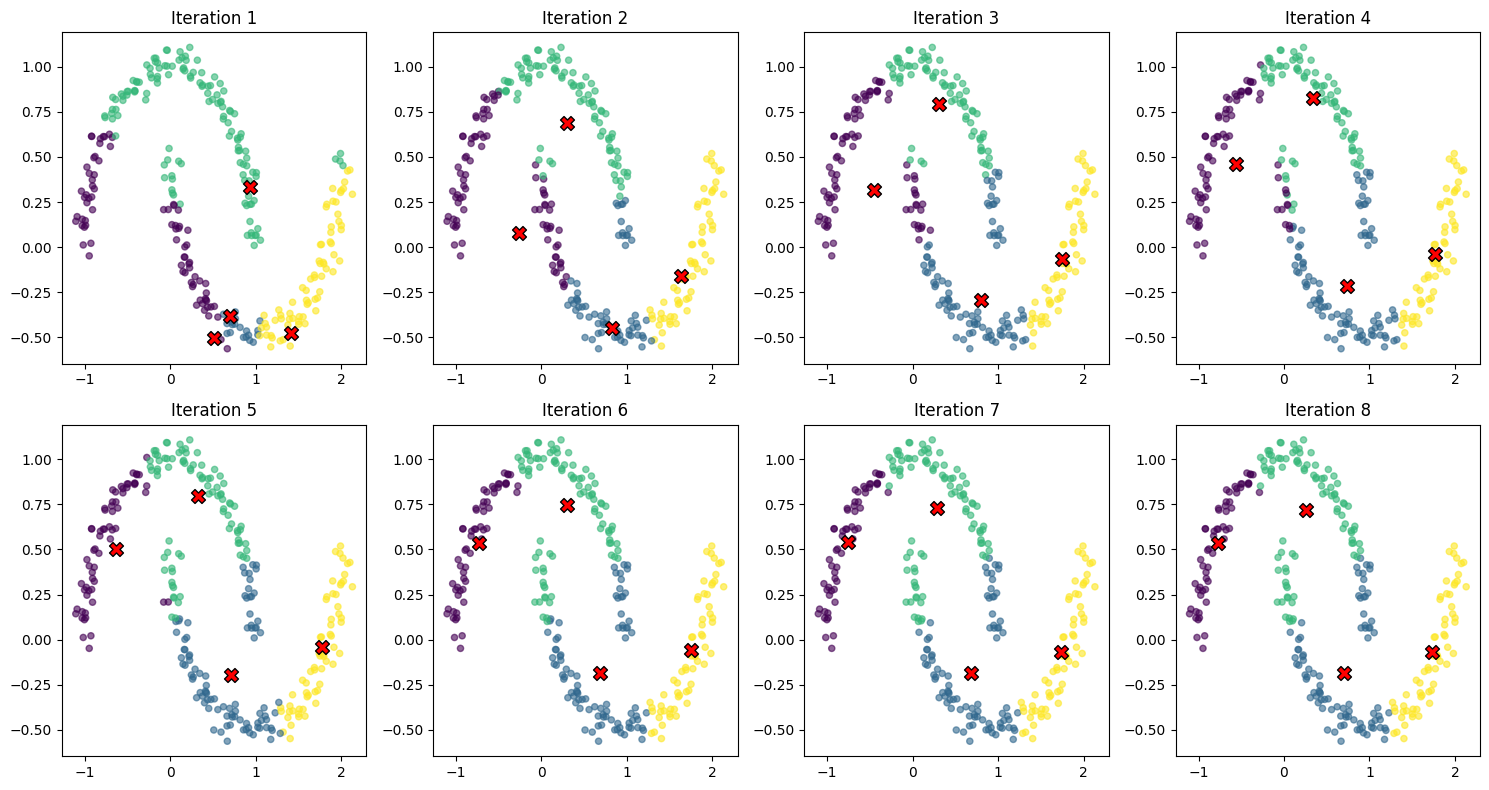

In [14]:
kmeans_nc_plot = KMeans(n_clusters=4)
kmeans_nc_plot.fit(X_non_convex)

iters = len(kmeans_nc_plot.centroids_history)
cols = min(4, iters)
rows = (iters + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(15, 4 * rows))
axes = np.array(axes).flatten()

for i in range(iters):
    ax = axes[i]
    ax.scatter(X_non_convex[:, 0], X_non_convex[:, 1], c=kmeans_nc_plot.labels_history[i], cmap='viridis', s=20, alpha=0.6)
    ax.scatter(kmeans_nc_plot.centroids_history[i][:, 0], kmeans_nc_plot.centroids_history[i][:, 1],
               c='red', marker='X', s=100, edgecolors='black')
    ax.set_title(f'Iteration {i+1}')

for i in range(iters, len(axes)):
    axes[i].axis('off')

plt.tight_layout()
plt.show()

Explain the output of k-means for both datasets. Focus on when k-means successfully classifies the dataset and when it fails. Provide an explanation for why this happens.

> **VIDEO REMINDER (Video 1/2):** Record a video explaining the K-Means results on both datasets — when it succeeds (convex) and when it fails (non-convex) and why.

K-Means works well on the convex dataset because the clusters are roughly spherical and well separated, so the K-Means boundaries between centroids align with the actual cluster boundaries.

On the non-convex (half moons) dataset it fails. K-Means can only create linear boundaries, so it can't follow the curved shape of the two half moons. With k=4 it splits the data into 4 roughly equal-area regions instead of capturing the two moon shapes. The algorithm isn't wrong — it finds the optimal solution for its objective — but the objective (minimizing squared distances to centroids) simply doesn't match the structure of non-convex data.

## Part 2 - PCA (50%)

In this part you will implement the PCA algorithm on the MNIST dataset.<br>
**As in the first part, your implementation will be based on the numpy package only.**

### **1. Useful packages**

In [15]:
import matplotlib.pyplot as plt
import numpy as np

from sklearn.datasets import fetch_openml

### **2. Data**

Load the MNIST dataset from sklearn datasets.

In [16]:
X, y = fetch_openml('mnist_784', version=1, return_X_y=True, as_frame=False)

### **3. PCA**

Implement the PCA algorithm here.<br> Don't forget to center the data, i.e. make the mean of the columns of the dataset to 0.

In [17]:
class PCA:
    def __init__(self):
        self.V = None

    def fit(self, X):
        # Calculate and store the mean to center the data
        self.mean = np.mean(X, axis=0)
        X_centered = X - self.mean

        # Calculate the covariance matrix (X^T * X)
        XTX = np.dot(X_centered.T, X_centered)

        # Calculate eigenvalues and eigenvectors
        # eigh is used for symmetric matrices like covariance matrices
        eigenvalues, eigenvectors = np.linalg.eigh(XTX)

        # Sort eigenvectors by eigenvalues in descending order
        sorted_indices = np.argsort(eigenvalues)[::-1]
        self.V = eigenvectors[:, sorted_indices]

    def transform(self, X, n_dimentions):
        # Center the data using the mean calculated in fit
        X_centered = X - self.mean

        # Take the top 'n_dimentions' eigenvectors
        V_r = self.V[:, :n_dimentions]

        # Project the data
        X_reduced = np.dot(X_centered, V_r)

        return X_reduced

Run the algorithm on MNIST dataset.

In [18]:
pca = PCA()
pca.fit(X)

# transform the data to the top 2 principal components
X_reduced = pca.transform(X, 2)

Plot the data in the top 2 principal component space.

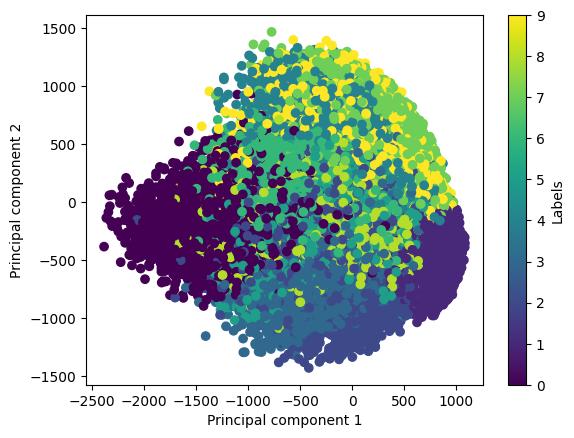

In [19]:
y = [int(label) for label in y]
fig, ax = plt.subplots()
scatter = ax.scatter(X_reduced[:, 0], X_reduced[:, 1], c=y, cmap='viridis')

cbar = fig.colorbar(scatter)
cbar.set_label('Labels')

ax.set_xlabel('Principal component 1')
ax.set_ylabel('Principal component 2')

plt.show()

As we showed in class, $V\in \mathbb{R}^{d\times r}$  is the matrix whose colmns are the top  $r$ eigenvectors of $X^TX$. That is, the eigenvectors that correspond to the  $r$ largest eigenvalues. <br>
In the cell below, Write a code that plots the two matrices $V^TV$ and $VV^T$ (you can choose r=10).<br>
Explain the differences between the two matrices

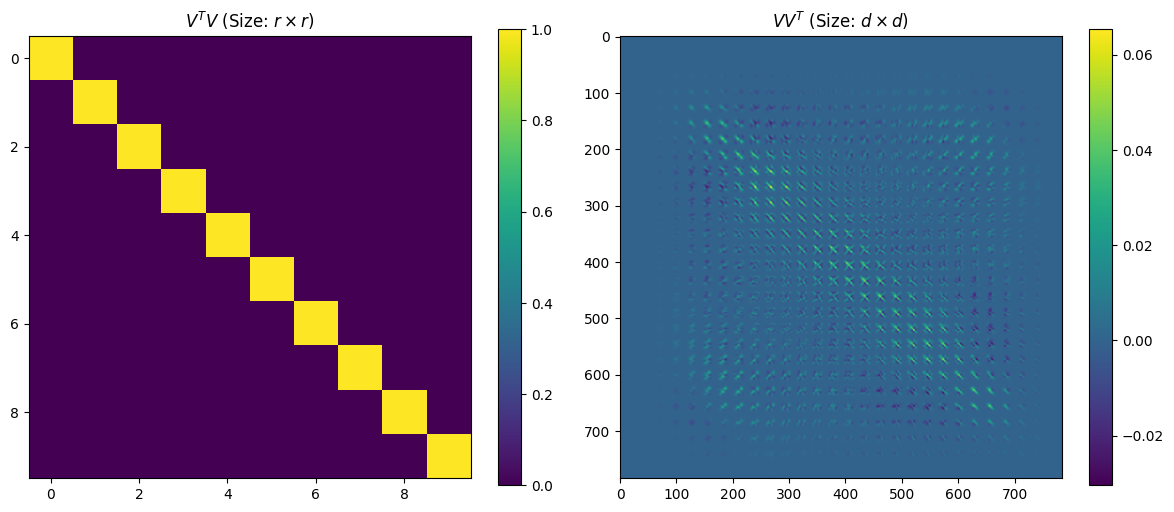

In [20]:
r = 10
# Extract the top r eigenvectors
V_r = pca.V[:, :r]

# Calculate V^T V and V V^T
VTV = np.dot(V_r.T, V_r)
VVT = np.dot(V_r, V_r.T)

# Plot the matrices
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# V^T V Plot
im1 = axes[0].imshow(VTV, cmap='viridis')
axes[0].set_title('$V^T V$ (Size: $r \\times r$)')
fig.colorbar(im1, ax=axes[0])

# V V^T Plot
im2 = axes[1].imshow(VVT, cmap='viridis')
axes[1].set_title('$V V^T$ (Size: $d \\times d$)')
fig.colorbar(im2, ax=axes[1])

plt.tight_layout()
plt.show()


Your Explanation:

$V^TV$ is $r \times r$ and equals the identity matrix, because the columns of $V_r$ are orthonormal (each column has norm 1 and is orthogonal to all others).

$VV^T$ is $d \times d$ and is a projection matrix onto the $r$-dimensional subspace spanned by the top $r$ principal components. It's not the identity because $r < d$ — it only keeps the component of a vector along the principal directions and discards the rest.

> **VIDEO REMINDER (Video 2/2):** Record a video explaining the difference between $V^TV$ and $VV^T$. Reference your plots above.

Now write a function that projects a sample to a n-dimentional space  and **recontsturct** it to the original space.

In [21]:
def pca_reconstruction(x, n_dimentions):
    # Center the sample
    x_centered = x - pca.mean

    # Get the top n eigenvectors
    V_r = pca.V[:, :n_dimentions]

    # Project to the lower-dimensional space
    x_reduced = np.dot(x_centered, V_r)

    # Reconstruct to the original space
    x_reconstructed = np.dot(x_reduced, V_r.T) + pca.mean

    return x_reconstructed

Now write code that samples a random image from the dataset, and uses the function above to project it into n-dimensional space and reconstruct it to the original space. <br><br>
Is the reconstructed image the original image?
<br><br>

Perform the reconstruction above from spaces of dimensions: 3, 10, 100.<br>


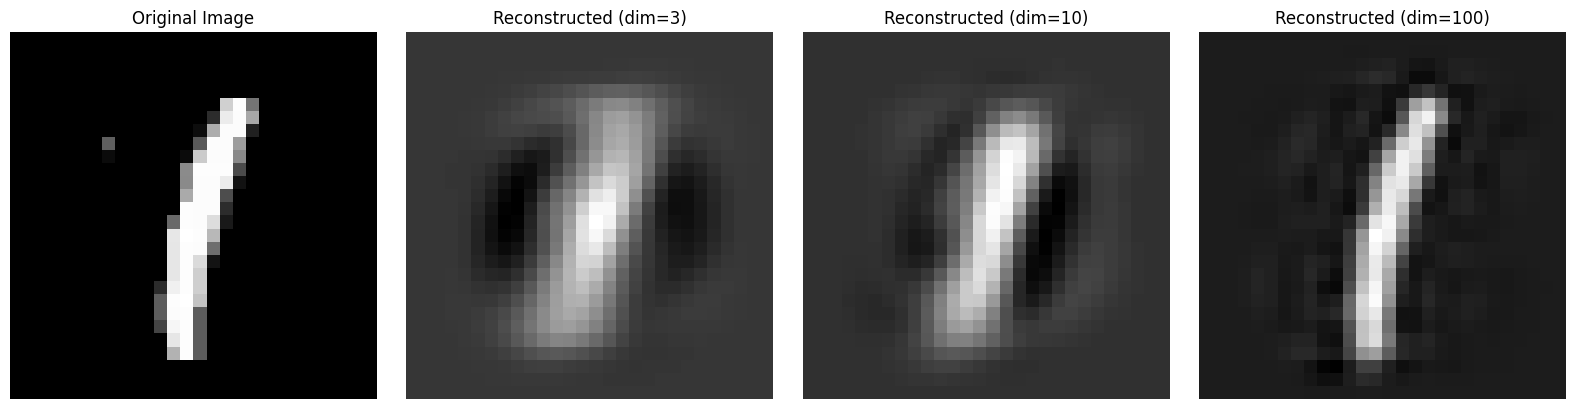

In [22]:
import random

# Sample a random image from the dataset
random_index = random.randint(0, X.shape[0] - 1)
original_image = X[random_index]

# Dimensions to test
dimensions = [3, 10, 100]
reconstructed_images = []

for dim in dimensions:
    reconstructed = pca_reconstruction(original_image, dim)
    reconstructed_images.append(reconstructed)

# Plot the original and reconstructed images
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

# Plot Original
axes[0].imshow(original_image.reshape(28, 28), cmap='gray')
axes[0].set_title("Original Image")
axes[0].axis('off')

# Plot Reconstructions
for i, dim in enumerate(dimensions):
    axes[i+1].imshow(reconstructed_images[i].reshape(28, 28), cmap='gray')
    axes[i+1].set_title(f"Reconstructed (dim={dim})")
    axes[i+1].axis('off')

plt.tight_layout()
plt.show()

So, to answer the last question:
No, the reconstructed image is not the original. Projecting to a lower-dimensional space loses information, so the reconstruction is only an approximation. With 3 dimensions the image is very blurry, with 10 it has some similar features, and with 100 it's close to the original but still not exactly the same.